In [14]:
# ==========================================================
# STEP 1: ENVIRONMENT SETUP & DATASET LOAD (no manual upload)
# ==========================================================
print("Installing cloud environment dependencies (RDKit, SHAP)...")
!pip install rdkit shap xgboost imbalanced-learn -q

import os
import io
import numpy as np
import pandas as pd
from google.colab import files

print("\n" + "="*60)
print("SYSTEM ACTIVE: INITIALIZING TOXICOLOGY PIPELINE ENGINE")
print("="*60)

DATA_URL = "https://raw.githubusercontent.com/sakshihulke11-oss/KidneyTox-QSAR/main/Nephrotoxicity_Smallmolecules_dataset.csv"

try:
    df = pd.read_csv(DATA_URL)
    print(f"[INFO] Dataset loaded successfully from: {DATA_URL}")
except Exception as e:
    print(f"[ERROR] Could not load dataset from {DATA_URL}. Error: {e}")
    print("Please ensure the 'Nephrotoxicity_Smallmolecules_dataset.csv' file is available at this path.")
    print("If sharing, consider using a public URL for the dataset.")
    raise FileNotFoundError("Dataset loading failed. Please verify DATA_URL or ensure the file is present.")

# Sanitize dataset from structural header artifacts
if str(df.iloc[0]["Compound"]).upper() == "ID":
    df = df.iloc[1:].reset_index(drop=True)

df["Toxicity"] = df["Toxicity"].astype(int)
print(f"\n[SUCCESS] Dataset loaded. Dimensions: {df.shape}")
print("\n--- Clinical Class Distribution (0 = Safe, 1 = Toxic) ---")
print(df["Toxicity"].value_counts())

Installing cloud environment dependencies (RDKit, SHAP)...

SYSTEM ACTIVE: INITIALIZING TOXICOLOGY PIPELINE ENGINE
[INFO] Dataset loaded successfully from: https://raw.githubusercontent.com/sakshihulke11-oss/KidneyTox-QSAR/main/Nephrotoxicity_Smallmolecules_dataset.csv

[SUCCESS] Dataset loaded. Dimensions: (565, 4)

--- Clinical Class Distribution (0 = Safe, 1 = Toxic) ---
Toxicity
1    287
0    278
Name: count, dtype: int64


TRANSLATING RAW TEXT SMILES TO 2D CHEMICAL GRAPHICS


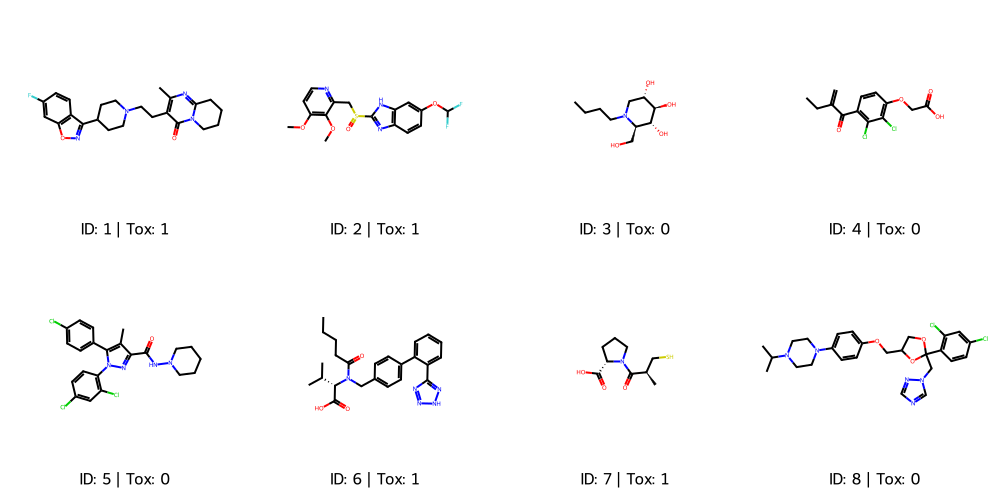

In [15]:
# ==========================================================
# STEP 2: CHEMICAL STRUCTURE VISUALIZATION FROM TEXT (SMILES)
# ==========================================================
from rdkit import Chem
from rdkit.Chem import Draw

print("="*60)
print("TRANSLATING RAW TEXT SMILES TO 2D CHEMICAL GRAPHICS")
print("="*60)

# Isolate the first 8 molecules from the text column to display to the examiners
viz_molecules = [Chem.MolFromSmiles(str(smi)) for smi in df["Smiles"].head(8)]
viz_labels = [f"ID: {comp} | Tox: {tox}" for comp, tox in zip(df["Compound"].head(8), df["Toxicity"].head(8))]

# Render the layout grid
img = Draw.MolsToGridImage(
    viz_molecules,
    molsPerRow=4,
    subImgSize=(250, 250),
    legends=viz_labels
)
display(img)

In [16]:
# ==========================================================
# STEP 3: COMPUTING MOLECULAR PROPERTY & FINGERPRINT MATRICES
# ==========================================================
!pip install rdkit -q
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs

print("="*60)
print("EXTRACTING CHEMINFORMATIC DESCRIPTORS & BINARY BARCODES")
print("="*60)

molecules = [Chem.MolFromSmiles(str(smi)) for smi in df["Smiles"]]
descriptor_names = [x[0] for x in Descriptors._descList]
descriptor_values = []

# Map physical properties
for mol in molecules:
    if mol is None:
        descriptor_values.append([np.nan]*len(descriptor_names))
    else:
        values = []
        for name, func in Descriptors._descList:
            try: values.append(func(mol))
            except: values.append(np.nan)
        descriptor_values.append(values)

descriptor_df = pd.DataFrame(descriptor_values, columns=descriptor_names)

# Compute 2048-bit structural Morgan circular fingerprints
fingerprints = []
for mol in molecules:
    arr = np.zeros((2048,), dtype=int)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        DataStructs.ConvertToNumpyArray(fp, arr)
    fingerprints.append(arr)

fingerprint_df = pd.DataFrame(fingerprints, columns=[f"FP_{i}" for i in range(2048)])

# Merge features and strip out zero-variance noise columns
X = pd.concat([descriptor_df, fingerprint_df], axis=1)
X.replace([np.inf, -np.inf], np.nan, inplace=True)
missing = X.isnull().mean()
X = X.loc[:, missing < 0.20]
X = X.fillna(X.median(numeric_only=True))
X = X.loc[:, X.var() > 0]
X.columns = X.columns.astype(str)

# Perform strict Train/Test mask partitions matching the original protocol
train_mask = df["Set"] == "Train"
test_mask = df["Set"] == "Test"

X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)
y_train = df.loc[train_mask, "Toxicity"].reset_index(drop=True)
y_test = df.loc[test_mask, "Toxicity"].reset_index(drop=True)

# ================== FIX 2: LOG SPLIT SIZES ==================
print(f"\nTraining set size: {X_train.shape[0]} compounds ({X_train.shape[1]} features)")
print(f"Test set size: {X_test.shape[0]} compounds ({X_test.shape[1]} features)")
print(f"Train class balance:\n{y_train.value_counts()}")
print(f"Test class balance:\n{y_test.value_counts()}")

EXTRACTING CHEMINFORMATIC DESCRIPTORS & BINARY BARCODES


[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerator
[05:04:58] DEPRECATION WARNING: please use MorganGenerat


Training set size: 452 compounds (2175 features)
Test set size: 113 compounds (2175 features)
Train class balance:
Toxicity
1    234
0    218
Name: count, dtype: int64
Test class balance:
Toxicity
0    60
1    53
Name: count, dtype: int64


In [17]:
# ==========================================================
# STEP 4: MUTUAL INFORMATION ENTROPY FILTER & SMOTE
# ==========================================================
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

print("="*60)
print("REDUCING DIMENSIONALITY & RESOLVING BIAS")
print("="*60)

# Run Mutual Information score calculations
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

TOP_FEATURES = 300
selected_features = mi_series.head(TOP_FEATURES).index.tolist()

X_train = X_train[selected_features]
X_test = X_test[selected_features]
print(f"[INFO] Reduced matrix noise down to the Top {TOP_FEATURES} critical features.")

# Deploy SMOTE engine to address the minority toxicity class
smote_engine = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote_engine.fit_resample(X_train, y_train)
print("\n--- Balanced Training Profile Counts After SMOTE Synthetic Expansion ---")
print(pd.Series(y_train_smote).value_counts())

REDUCING DIMENSIONALITY & RESOLVING BIAS
[INFO] Reduced matrix noise down to the Top 300 critical features.

--- Balanced Training Profile Counts After SMOTE Synthetic Expansion ---
Toxicity
1    234
0    234
Name: count, dtype: int64


EXECUTING MODEL TOURNAMENT & OPTIMIZATION


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

FINAL TOURNAMENT LEADERBOARD FOR JURY REVIEW
        Model  Accuracy  ROC-AUC   PR-AUC  F1 Score
Random Forest  0.787611 0.875943 0.869831  0.773585
      XGBoost  0.814159 0.898113 0.880308  0.810811
          DNN  0.699115 0.776415 0.751778  0.685185


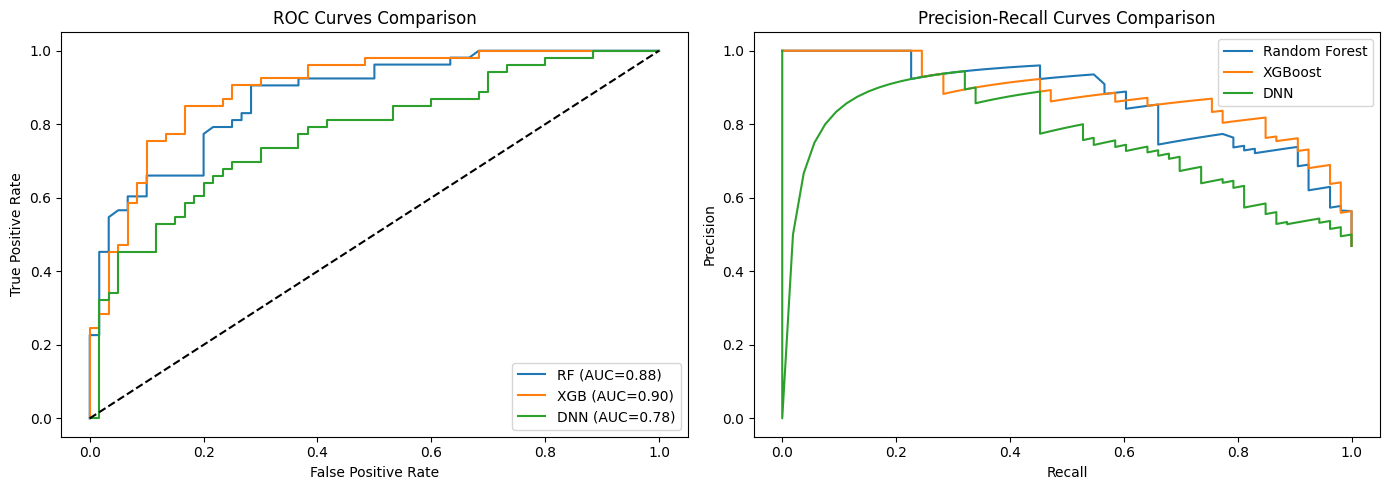

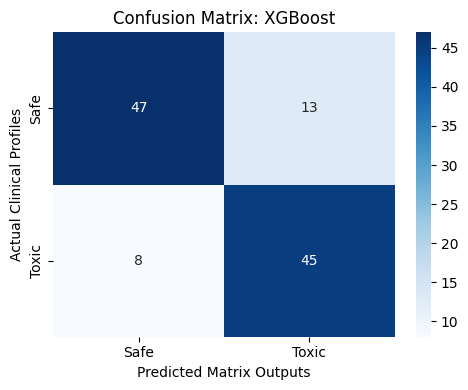


[INFO] Initializing Shapley value structural attributions...


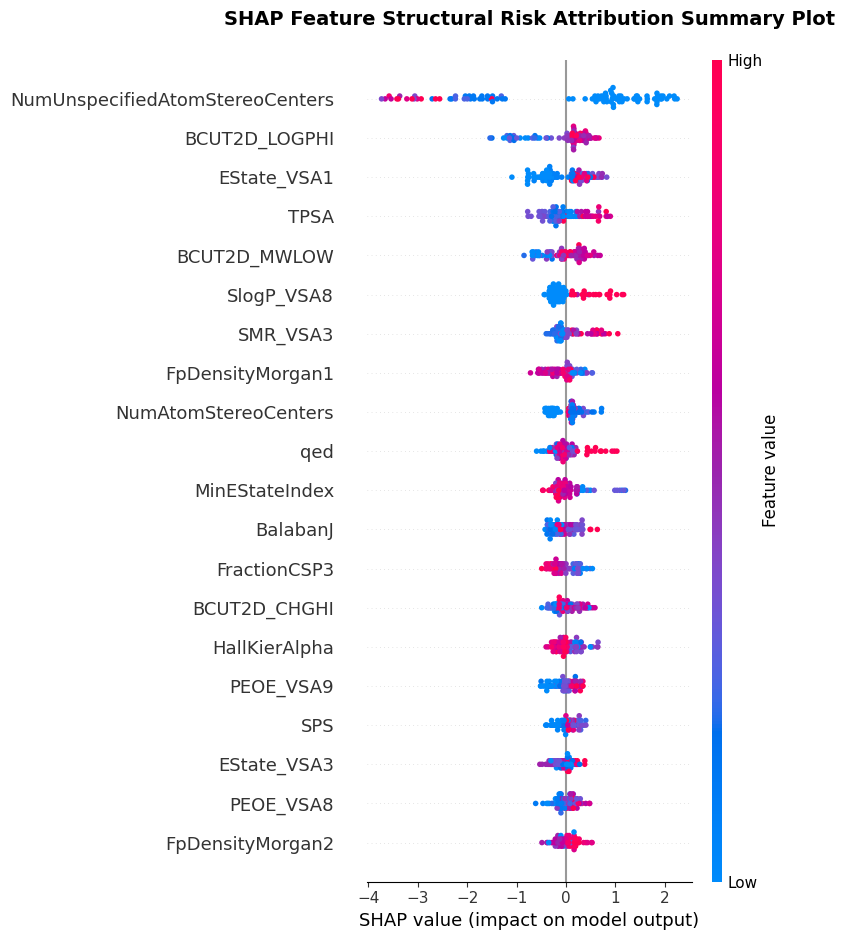


**************************************************
PRODUCTION DEMO TESTING (LIVE UNSEEN SCREENING)
**************************************************


[05:09:42] DEPRECATION WARNING: please use MorganGenerator


Target Compound Query String (Aspirin): CC(=O)OC1=CC=CC=C1C(=O)O


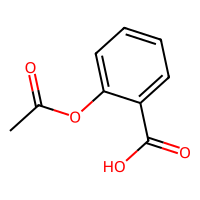

Computed Predictive Nephrotoxicity Probability: 0.0130
Diagnostic Action Verdict: [ NON-NEPHROTOXIC ] 

PIPELINE EXECUTION TERMINATED SUCCESSFULLY


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# ==========================================================
# STEP 5: HYPERPARAMETER TUNING, METRICS, SHAP & LIVE SCREENING
# ==========================================================
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from google.colab import files

print("="*60)
print("EXECUTING MODEL TOURNAMENT & OPTIMIZATION")
print("="*60)

# 1. Random Forest Optimization
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = {"n_estimators": [300, 500], "max_depth": [10, 15, None], "min_samples_leaf": [1, 2]}
rf_search = GridSearchCV(rf_base, rf_grid, cv=5, scoring="roc_auc", n_jobs=-1)
rf_search.fit(X_train_smote, y_train_smote)
rf_best = rf_search.best_estimator_

# 2. XGBoost Optimization
xgb_base = XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42)
xgb_grid = {"n_estimators": [300, 500], "learning_rate": [0.05, 0.1], "max_depth": [4, 6, 8]}
xgb_search = GridSearchCV(xgb_base, xgb_grid, cv=5, scoring="roc_auc", n_jobs=-1)
xgb_search.fit(X_train_smote, y_train_smote)
xgb_best = xgb_search.best_estimator_

# 3. Deep Neural Network Optimization
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train_smote)
X_test_scaled = feature_scaler.transform(X_test)

dnn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.30),
    Dense(128, activation='relu'),
    Dropout(0.30),
    Dense(64, activation='relu'),
    Dropout(0.20),
    Dense(1, activation='sigmoid')
])
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
dnn_model.fit(X_train_scaled, y_train_smote, validation_split=0.2, epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

# Calculate testing results across the tournament
rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)[:, 1]

xgb_pred = xgb_best.predict(X_test)
xgb_prob = xgb_best.predict_proba(X_test)[:, 1]

dnn_prob = dnn_model.predict(X_test_scaled).flatten()
dnn_pred = (dnn_prob >= 0.5).astype(int)

# Render performance metrics table
def compile_metrics(name, y_true, pred, prob):
    return [name, accuracy_score(y_true, pred), roc_auc_score(y_true, prob), average_precision_score(y_true, prob), f1_score(y_true, pred)]

report = [
    compile_metrics("Random Forest", y_test, rf_pred, rf_prob),
    compile_metrics("XGBoost", y_test, xgb_pred, xgb_prob),
    compile_metrics("DNN", y_test, dnn_pred, dnn_prob)
]
results_df = pd.DataFrame(report, columns=["Model", "Accuracy", "ROC-AUC", "PR-AUC", "F1 Score"])
print("\n" + "="*50 + "\nFINAL TOURNAMENT LEADERBOARD FOR JURY REVIEW\n" + "="*50)
print(results_df.to_string(index=False))

# Plot baseline metrics curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for label, prob in [("RF", rf_prob), ("XGB", xgb_prob), ("DNN", dnn_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax1.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, prob):.2f})")
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate"); ax1.set_title("ROC Curves Comparison"); ax1.legend()

for label, prob in [("Random Forest", rf_prob), ("XGBoost", xgb_prob), ("DNN", dnn_prob)]:
    p, r, _ = precision_recall_curve(y_test, prob)
    ax2.plot(r, p, label=label)
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision"); ax2.set_title("Precision-Recall Curves Comparison"); ax2.legend()
plt.tight_layout(); plt.show()

# Extract top performing configuration confusion heatmap
winner_name = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Safe", "Toxic"], yticklabels=["Safe", "Toxic"])
plt.xlabel("Predicted Matrix Outputs"); plt.ylabel("Actual Clinical Profiles"); plt.title(f"Confusion Matrix: {winner_name}")
plt.tight_layout(); plt.show()

# Generate SHAP value attributions
print("\n[INFO] Initializing Shapley value structural attributions...")
shap_explainer = shap.TreeExplainer(xgb_best)
shap_sample = X_test.sample(min(100, len(X_test)), random_state=42)
shap_computed = shap_explainer.shap_values(shap_sample)
shap_display = shap_computed[1] if isinstance(shap_computed, list) else shap_computed

# Dynamic layout configuration to stop text title from crashing into descriptor text strings
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_display, shap_sample, show=False)
plt.title("SHAP Feature Structural Risk Attribution Summary Plot", fontsize=14, pad=25, fontweight='bold')
plt.tight_layout()
plt.savefig("SHAP_Summary.png", dpi=300, bbox_inches='tight')
plt.show()

# Live Screening Production Engine Execution Block
def live_screening_engine(smiles_string):
    mol_obj = Chem.MolFromSmiles(smiles_string)
    if mol_obj is None: raise ValueError("Invalid chemical SMILES pattern string parsed.")
    desc_list = [func(mol_obj) if mol_obj else np.nan for name, func in Descriptors._descList]
    fp_vect = AllChem.GetMorganFingerprintAsBitVect(mol_obj, radius=2, nBits=2048)
    fp_arr = np.zeros((2048,), dtype=int); DataStructs.ConvertToNumpyArray(fp_vect, fp_arr)
    parsed_desc = pd.DataFrame([desc_list], columns=descriptor_names)
    parsed_fp = pd.DataFrame([fp_arr], columns=[f"FP_{i}" for i in range(2048)])
    combined = pd.concat([parsed_desc, parsed_fp], axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)
    return combined.reindex(columns=selected_features, fill_value=0)

print("\n" + "*"*50 + "\nPRODUCTION DEMO TESTING (LIVE UNSEEN SCREENING)\n" + "*"*50)
aspirin_smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"
parsed_payload = live_screening_engine(aspirin_smiles)
live_prob_score = xgb_best.predict_proba(parsed_payload)[0][1]

print(f"Target Compound Query String (Aspirin): {aspirin_smiles}")
display(Draw.MolToImage(Chem.MolFromSmiles(aspirin_smiles), size=(200, 200)))
print(f"Computed Predictive Nephrotoxicity Probability: {live_prob_score:.4f}")
print(f"Diagnostic Action Verdict: {'[ NEPHROTOXIC ] ❌' if live_prob_score >= 0.5 else '[ NON-NEPHROTOXIC ] '}")
print("\n" + "="*60 + "\nPIPELINE EXECUTION TERMINATED SUCCESSFULLY\n" + "="*60)

files.download("SHAP_Summary.png")

In [20]:
# ==========================================================
# STEP 6: ROBUST 5-FOLD CROSS-VALIDATED PERFORMANCE ESTIMATE
# ==========================================================
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np

y_full = df["Toxicity"].reset_index(drop=True)

cv_pipeline = ImbPipeline([
    ("feature_select", SelectKBest(score_func=mutual_info_classif, k=300)),
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("xgb", XGBClassifier(
        objective="binary:logistic", eval_metric="logloss", random_state=42,
        n_estimators=xgb_best.n_estimators,
        learning_rate=xgb_best.learning_rate,
        max_depth=xgb_best.max_depth
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, X, y_full, cv=skf, scoring="roc_auc", n_jobs=-1)

print("5-Fold Stratified CV ROC-AUC scores:", np.round(cv_scores, 4))
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}  |  Std Dev: {cv_scores.std():.4f}")
print(f"Report to jury as: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-Fold Stratified CV ROC-AUC scores: [0.8116 0.8339 0.8409 0.8023 0.8139]
Mean ROC-AUC: 0.8205  |  Std Dev: 0.0145
Report to jury as: 0.821 ± 0.014
